# PipelinePilot AI - Analytics Intelligence Engine

**Company:** Veloryn (veloryn.dev)  
**Product:** PipelinePilot AI - Agentic lead capture, scoring, conversion

---

## The Problem
SMBs lose 20-30% revenue to lead leakage or churn. They don't know:
- **WHO** will convert (prediction)
- **WHY** they convert (explanation)
- **WHAT** to improve (prescription)
- **WHO** to target (segmentation)

## Our Solution
This notebook powers the **Score**, **Nurture**, and **Convert** agents:
- **SEM** finds CAUSAL drivers of conversion
- **Key Driver Analysis** ranks WHERE to invest effort
- **Uplift Modeling** decides WHO to target (4 segments)
- **SHAP** explains WHY each lead scored the way it did

---

## 1. Setup & Configuration

Configure your vertical, install dependencies, and set analysis parameters.

In [1]:
# =============================================================================
# INSTALL DEPENDENCIES (run once)
# =============================================================================
import subprocess
import sys

def install_packages():
    packages = [
        'numpy', 'pandas', 'scipy', 'statsmodels',
        'scikit-learn', 'matplotlib', 'seaborn',
        'semopy', 'factor_analyzer', 'shap',
        'plotly', 'ipywidgets'
    ]
    for pkg in packages:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])
    print('All packages installed successfully!')

# Uncomment to install:
# install_packages()

In [2]:
# =============================================================================
# IMPORTS
# =============================================================================
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import f_oneway, spearmanr, pearsonr
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns

# Set style - colourblind-safe palette
plt.style.use('seaborn-v0_8-whitegrid')
CB_PALETTE = ['#0077BB', '#33BBEE', '#009988', '#EE7733', '#CC3311', '#EE3377', '#BBBBBB']
sns.set_palette(CB_PALETTE)

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.3f}'.format)

print('Imports complete. PipelinePilot Analytics Engine ready.')

Imports complete. PipelinePilot Analytics Engine ready.


In [3]:
# =============================================================================
# VERTICAL CONFIGURATION
# =============================================================================
# Change this ONE variable to switch between business types
ACTIVE_VERTICAL = 'cafe'  # Options: 'cafe', 'salon', 'agency', 'fitness'

# =============================================================================
# COMPLETE VERTICAL DEFINITIONS
# =============================================================================
VERTICALS = {
    'cafe': {
        'name': 'Cafe / Cloud Kitchen',
        'example': 'Third Wave Coffee, Koramangala',
        'outcome_var': 'churned',
        'outcome_label': 'Customer Churn',
        'treatment_var': 'received_loyalty_offer',
        'treatment_label': 'Loyalty Offer',
        'constructs': {
            'FoodQuality': {
                'indicators': ['taste_rating', 'freshness_rating', 'presentation_rating', 'menu_variety'],
                'mean_range': (4.8, 5.3), 'std': 0.8, 'loading_range': (0.75, 0.90),
                'is_strength': True
            },
            'Service': {
                'indicators': ['staff_friendliness', 'service_speed', 'order_accuracy', 'staff_knowledge'],
                'mean_range': (4.2, 4.7), 'std': 0.9, 'loading_range': (0.70, 0.85),
                'is_strength': False
            },
            'Ambience': {
                'indicators': ['cleanliness_rating', 'seating_comfort', 'noise_level', 'decor_vibe'],
                'mean_range': (4.5, 5.0), 'std': 0.85, 'loading_range': (0.72, 0.88),
                'is_strength': False
            },
            'Value': {
                'indicators': ['price_fairness', 'portion_size', 'promo_satisfaction'],
                'mean_range': (3.2, 3.7), 'std': 1.0, 'loading_range': (0.70, 0.85),
                'is_strength': False  # Weakness - premium pricing
            },
            'Digital': {
                'indicators': ['app_ease', 'delivery_speed', 'online_menu_quality'],
                'mean_range': (4.0, 4.5), 'std': 0.95, 'loading_range': (0.72, 0.88),
                'is_strength': False
            }
        },
        'demographics': {
            'age': {'type': 'continuous', 'mean': 32, 'std': 8},
            'gender': {'type': 'categorical', 'categories': ['M', 'F', 'Other'], 'probs': [0.45, 0.50, 0.05]},
            'order_channel': {'type': 'categorical', 'categories': ['Dine-in', 'Swiggy', 'Zomato', 'Direct App'], 'probs': [0.35, 0.25, 0.25, 0.15]},
            'distance_km': {'type': 'continuous', 'mean': 3.5, 'std': 2.0},
            'tenure_months': {'type': 'continuous', 'mean': 8, 'std': 6}
        },
        'outcome_base_rate': 0.22,  # 22% churn rate
        'treatment_rate': 0.40,
        'avg_customer_value': 2500  # INR per month
    },
    
    'salon': {
        'name': 'High-End Salon / Spa',
        'example': 'Bodycraft, Toni&Guy - Koramangala',
        'outcome_var': 'churned',
        'outcome_label': 'Customer Churn (60+ days inactive)',
        'treatment_var': 'received_personalised_offer',
        'treatment_label': 'Personalised Offer',
        'constructs': {
            'ServiceQuality': {
                'indicators': ['stylist_skill_rating', 'consultation_quality', 'result_satisfaction', 'hygiene_rating'],
                'mean_range': (5.2, 5.6), 'std': 0.7, 'loading_range': (0.80, 0.92),
                'is_strength': True
            },
            'Experience': {
                'indicators': ['wait_time_rating', 'ambience_score', 'music_comfort', 'refreshments_quality'],
                'mean_range': (4.3, 4.8), 'std': 0.85, 'loading_range': (0.72, 0.85),
                'is_strength': False
            },
            'Pricing': {
                'indicators': ['value_for_money', 'transparency_rating', 'membership_satisfaction', 'discount_fairness'],
                'mean_range': (3.3, 3.8), 'std': 1.0, 'loading_range': (0.70, 0.85),
                'is_strength': False  # Weakness
            },
            'Convenience': {
                'indicators': ['booking_ease', 'location_accessibility', 'parking_availability', 'schedule_flexibility'],
                'mean_range': (3.8, 4.2), 'std': 0.95, 'loading_range': (0.70, 0.85),
                'is_strength': False  # Parking is an issue
            },
            'Loyalty': {
                'indicators': ['recommend_likelihood', 'return_intent', 'social_media_engagement', 'review_posted'],
                'mean_range': (4.5, 5.0), 'std': 0.9, 'loading_range': (0.75, 0.88),
                'is_strength': False
            }
        },
        'demographics': {
            'age': {'type': 'continuous', 'mean': 35, 'std': 10},
            'gender': {'type': 'categorical', 'categories': ['M', 'F', 'Other'], 'probs': [0.30, 0.65, 0.05]},
            'visit_frequency': {'type': 'continuous', 'mean': 2.5, 'std': 1.5},
            'avg_spend': {'type': 'continuous', 'mean': 3500, 'std': 2000},
            'service_category': {'type': 'categorical', 'categories': ['Hair', 'Skin', 'Spa', 'Nails'], 'probs': [0.45, 0.25, 0.20, 0.10]}
        },
        'outcome_base_rate': 0.25,
        'treatment_rate': 0.35,
        'avg_customer_value': 4000
    },
    
    'agency': {
        'name': 'Digital Marketing Agency (B2B)',
        'example': 'Bangalore DMA - 200+ leads/month',
        'outcome_var': 'converted',
        'outcome_label': 'Lead Conversion',
        'treatment_var': 'did_nurture_sequence',
        'treatment_label': 'Nurture Sequence',
        'constructs': {
            'LeadQuality': {
                'indicators': ['inquiry_detail_score', 'budget_mentioned', 'decision_maker_flag', 'referral_score'],
                'mean_range': (4.5, 5.0), 'std': 1.2, 'loading_range': (0.72, 0.88),
                'is_strength': False
            },
            'Engagement': {
                'indicators': ['email_open_rate', 'response_time_inv', 'pages_visited', 'content_downloads'],
                'mean_range': (6.0, 6.5), 'std': 1.0, 'loading_range': (0.75, 0.90),
                'is_strength': True
            },
            'ServiceFit': {
                'indicators': ['service_match_score', 'industry_alignment', 'scope_clarity', 'portfolio_relevance'],
                'mean_range': (4.8, 5.3), 'std': 1.1, 'loading_range': (0.73, 0.87),
                'is_strength': False
            },
            'Urgency': {
                'indicators': ['timeline_score', 'competitor_mentions', 'lead_initiated_followup', 'proposal_requested'],
                'mean_range': (3.5, 4.2), 'std': 1.3, 'loading_range': (0.70, 0.85),
                'is_strength': False
            },
            'BudgetReadiness': {
                'indicators': ['budget_range_stated', 'payment_discussed', 'contract_length_asked', 'roi_questions'],
                'mean_range': (2.8, 3.5), 'std': 1.4, 'loading_range': (0.70, 0.85),
                'is_strength': False  # Weakness - most don't state budget
            }
        },
        'demographics': {
            'lead_source': {'type': 'categorical', 'categories': ['Organic', 'Referral', 'LinkedIn', 'Paid'], 'probs': [0.30, 0.25, 0.25, 0.20]},
            'industry': {'type': 'categorical', 'categories': ['Tech', 'Retail', 'Healthcare', 'Finance', 'Other'], 'probs': [0.35, 0.20, 0.15, 0.15, 0.15]},
            'company_size': {'type': 'categorical', 'categories': ['1-10', '11-50', '51-200', '200+'], 'probs': [0.30, 0.35, 0.25, 0.10]}
        },
        'outcome_base_rate': 0.15,  # 15% conversion rate
        'treatment_rate': 0.50,
        'avg_customer_value': 150000  # INR per deal
    },
    
    'fitness': {
        'name': 'Fitness Studio / Gym',
        'example': 'Cult.fit, CrossFit - Koramangala',
        'outcome_var': 'membership_cancelled',
        'outcome_label': 'Membership Cancellation',
        'treatment_var': 'received_retention_campaign',
        'treatment_label': 'Retention Campaign',
        'constructs': {
            'FitnessResults': {
                'indicators': ['progress_tracking', 'trainer_quality', 'program_personalisation', 'goal_achievement'],
                'mean_range': (4.8, 5.2), 'std': 0.9, 'loading_range': (0.78, 0.92),
                'is_strength': True
            },
            'Facility': {
                'indicators': ['equipment_quality', 'cleanliness', 'crowd_level', 'locker_quality'],
                'mean_range': (4.3, 4.8), 'std': 0.85, 'loading_range': (0.72, 0.87),
                'is_strength': False
            },
            'Community': {
                'indicators': ['social_connection', 'class_energy', 'event_participation', 'peer_motivation'],
                'mean_range': (4.3, 4.7), 'std': 1.0, 'loading_range': (0.73, 0.88),
                'is_strength': False
            },
            'Convenience': {
                'indicators': ['class_timing_variety', 'location_ease', 'app_usability', 'cancellation_flexibility'],
                'mean_range': (4.0, 4.5), 'std': 0.95, 'loading_range': (0.70, 0.85),
                'is_strength': False
            },
            'Value': {
                'indicators': ['membership_fairness', 'hidden_fees_absent', 'trial_satisfaction', 'upgrade_value'],
                'mean_range': (3.5, 4.0), 'std': 1.1, 'loading_range': (0.70, 0.85),
                'is_strength': False  # Weakness
            }
        },
        'demographics': {
            'age': {'type': 'continuous', 'mean': 30, 'std': 7},
            'gender': {'type': 'categorical', 'categories': ['M', 'F', 'Other'], 'probs': [0.55, 0.42, 0.03]},
            'membership_type': {'type': 'categorical', 'categories': ['Monthly', 'Quarterly', 'Annual'], 'probs': [0.40, 0.35, 0.25]},
            'classes_per_week': {'type': 'continuous', 'mean': 3.5, 'std': 1.8}
        },
        'outcome_base_rate': 0.28,
        'treatment_rate': 0.45,
        'avg_customer_value': 3000
    }
}

# Load active configuration
CONFIG = VERTICALS[ACTIVE_VERTICAL]
print(f"""\n{'='*60}""")
print(f"ACTIVE VERTICAL: {CONFIG['name']}")
print(f"Example: {CONFIG['example']}")
print(f"Outcome: {CONFIG['outcome_label']} (base rate: {CONFIG['outcome_base_rate']*100:.0f}%)")
print(f"Treatment: {CONFIG['treatment_label']}")
print(f"Constructs: {', '.join(CONFIG['constructs'].keys())}")
print(f"{'='*60}\n")


ACTIVE VERTICAL: Cafe / Cloud Kitchen
Example: Third Wave Coffee, Koramangala
Outcome: Customer Churn (base rate: 22%)
Treatment: Loyalty Offer
Constructs: FoodQuality, Service, Ambience, Value, Digital



## 2. Data Generation / Loading

Generate realistic synthetic data using Cholesky decomposition to ensure proper factor structure.
In production, replace this with your actual data loading.

In [4]:
# =============================================================================
# SYNTHETIC DATA GENERATOR
# Uses Cholesky decomposition for realistic factor structure
# =============================================================================

def generate_synthetic_data(config, n_samples=5000, random_state=42):
    """
    Generate synthetic data with proper factor structure.
    
    For a cafe owner: This creates realistic customer data that mimics
    how your actual customers would rate different aspects of your business.
    """
    np.random.seed(random_state)
    data = {}
    latent_scores = {}
    
    # Generate latent factors (the hidden 'true' scores)
    n_constructs = len(config['constructs'])
    
    # Create correlation matrix for latent factors (moderate correlations)
    latent_corr = np.eye(n_constructs)
    for i in range(n_constructs):
        for j in range(i+1, n_constructs):
            latent_corr[i, j] = latent_corr[j, i] = np.random.uniform(0.2, 0.5)
    
    # Cholesky decomposition for correlated latent factors
    L = np.linalg.cholesky(latent_corr)
    latent_raw = np.random.normal(0, 1, (n_samples, n_constructs))
    latent_correlated = latent_raw @ L.T
    
    # Generate indicators from latent factors
    for idx, (construct_name, construct_config) in enumerate(config['constructs'].items()):
        latent_factor = latent_correlated[:, idx]
        latent_scores[construct_name] = latent_factor
        
        mean_low, mean_high = construct_config['mean_range']
        base_mean = np.random.uniform(mean_low, mean_high)
        
        for indicator in construct_config['indicators']:
            # Loading determines how strongly indicator reflects the latent factor
            loading = np.random.uniform(*construct_config['loading_range'])
            
            # Generate indicator: latent * loading + noise
            noise = np.random.normal(0, construct_config['std'] * np.sqrt(1 - loading**2), n_samples)
            indicator_values = base_mean + latent_factor * construct_config['std'] * loading + noise
            
            # Clip to 1-7 Likert scale
            data[indicator] = np.clip(indicator_values, 1, 7)
    
    # Generate demographics
    for demo_name, demo_config in config['demographics'].items():
        if demo_config['type'] == 'continuous':
            data[demo_name] = np.random.normal(demo_config['mean'], demo_config['std'], n_samples)
            if 'age' in demo_name:
                data[demo_name] = np.clip(data[demo_name], 18, 70).astype(int)
            elif 'distance' in demo_name or 'tenure' in demo_name or 'spend' in demo_name:
                data[demo_name] = np.clip(data[demo_name], 0.1, None)
        else:  # categorical
            data[demo_name] = np.random.choice(
                demo_config['categories'], 
                n_samples, 
                p=demo_config['probs']
            )
    
    # Generate outcome (influenced by latent factors)
    # Higher quality scores = lower churn probability (or higher conversion)
    outcome_var = config['outcome_var']
    is_negative_outcome = outcome_var in ['churned', 'membership_cancelled']
    
    # Weighted combination of latent factors
    weights = np.random.uniform(0.1, 0.4, n_constructs)
    weights = weights / weights.sum()
    
    combined_score = sum(latent_scores[c] * w for c, w in zip(config['constructs'].keys(), weights))
    
    # Convert to probability
    base_rate = config['outcome_base_rate']
    if is_negative_outcome:
        # Higher scores = lower churn
        prob = 1 / (1 + np.exp(combined_score * 0.8 - np.log(base_rate / (1 - base_rate))))
    else:
        # Higher scores = higher conversion
        prob = 1 / (1 + np.exp(-combined_score * 0.8 + np.log((1 - base_rate) / base_rate)))
    
    data[outcome_var] = (np.random.random(n_samples) < prob).astype(int)
    
    # Generate treatment with uplift effect
    treatment_var = config['treatment_var']
    data[treatment_var] = (np.random.random(n_samples) < config['treatment_rate']).astype(int)
    
    # Uplift effect: treatment reduces churn / increases conversion for some segments
    # Persuadables: medium latent scores
    persuadable_mask = (combined_score > -0.5) & (combined_score < 0.5) & (data[treatment_var] == 1)
    if is_negative_outcome:
        data[outcome_var][persuadable_mask] = (np.random.random(persuadable_mask.sum()) < base_rate * 0.5).astype(int)
    else:
        data[outcome_var][persuadable_mask] = (np.random.random(persuadable_mask.sum()) < base_rate * 1.8).astype(int)
    
    df = pd.DataFrame(data)
    return df, latent_scores

# Generate data
N_SAMPLES = 5000
df, latent_scores = generate_synthetic_data(CONFIG, n_samples=N_SAMPLES)

print(f"\nGenerated {len(df):,} records for {CONFIG['name']}")
print(f"\nOutcome Distribution ({CONFIG['outcome_var']}):")
print(df[CONFIG['outcome_var']].value_counts(normalize=True).round(3))
print(f"\nTreatment Distribution ({CONFIG['treatment_var']}):")
print(df[CONFIG['treatment_var']].value_counts(normalize=True).round(3))


Generated 5,000 records for Cafe / Cloud Kitchen

Outcome Distribution (churned):
churned
0   0.797
1   0.203
Name: proportion, dtype: float64

Treatment Distribution (received_loyalty_offer):
received_loyalty_offer
0   0.596
1   0.404
Name: proportion, dtype: float64


In [5]:
# =============================================================================
# DATA QUALITY SUMMARY
# =============================================================================

# Get all indicator columns
all_indicators = []
for construct_config in CONFIG['constructs'].values():
    all_indicators.extend(construct_config['indicators'])

print("\n" + "="*60)
print("CONSTRUCT PERFORMANCE SUMMARY")
print("(For CEO: Where are we strong? Where do we need to improve?)")
print("="*60 + "\n")

construct_means = {}
for construct_name, construct_config in CONFIG['constructs'].items():
    indicators = construct_config['indicators']
    means = df[indicators].mean()
    construct_mean = means.mean()
    construct_means[construct_name] = construct_mean
    
    status = "STRENGTH" if construct_config['is_strength'] else (
        "WEAKNESS" if construct_mean < 4.0 else "NEUTRAL"
    )
    status_emoji = {"STRENGTH": "[+]", "WEAKNESS": "[-]", "NEUTRAL": "[~]"}[status]
    
    print(f"{status_emoji} {construct_name}: {construct_mean:.2f}/7.0 ({status})")
    for ind in indicators:
        print(f"    - {ind}: {df[ind].mean():.2f}")
    print()

print("\n" + "="*60)
print("KEY INSIGHT FOR INVESTORS:")
weakest = min(construct_means, key=construct_means.get)
strongest = max(construct_means, key=construct_means.get)
print(f"Strongest dimension: {strongest} ({construct_means[strongest]:.2f})")
print(f"Weakest dimension: {weakest} ({construct_means[weakest]:.2f})")
print(f"Improvement opportunity: {(construct_means[strongest] - construct_means[weakest]):.2f} points")
print("="*60)


CONSTRUCT PERFORMANCE SUMMARY
(For CEO: Where are we strong? Where do we need to improve?)

[+] FoodQuality: 4.88/7.0 (STRENGTH)
    - taste_rating: 4.88
    - freshness_rating: 4.88
    - presentation_rating: 4.88
    - menu_variety: 4.89

[~] Service: 4.53/7.0 (NEUTRAL)
    - staff_friendliness: 4.52
    - service_speed: 4.53
    - order_accuracy: 4.51
    - staff_knowledge: 4.54

[~] Ambience: 4.94/7.0 (NEUTRAL)
    - cleanliness_rating: 4.95
    - seating_comfort: 4.94
    - noise_level: 4.95
    - decor_vibe: 4.94

[-] Value: 3.58/7.0 (WEAKNESS)
    - price_fairness: 3.59
    - portion_size: 3.59
    - promo_satisfaction: 3.57

[~] Digital: 4.23/7.0 (NEUTRAL)
    - app_ease: 4.22
    - delivery_speed: 4.24
    - online_menu_quality: 4.23


KEY INSIGHT FOR INVESTORS:
Strongest dimension: Ambience (4.94)
Weakest dimension: Value (3.58)
Improvement opportunity: 1.36 points


## 3. SEM Readiness Gate

Before running complex SEM analysis, we check if your data supports it.
If not, we gracefully degrade to simpler methods.

In [6]:
# =============================================================================
# SEM READINESS GATE - Automated Decision Tree
# =============================================================================

def check_sem_readiness(df, config, min_samples=200, min_indicators_per_construct=3):
    """
    Determine if data is suitable for full SEM analysis.
    
    For a cafe owner: This checks if we have enough data to find
    the real causes of customer churn, not just correlations.
    """
    results = {
        'sem_ready': True,
        'checks': [],
        'recommendation': '',
        'fallback_method': None
    }
    
    # Check 1: Sample size
    n_samples = len(df)
    sample_ok = n_samples >= min_samples
    results['checks'].append({
        'name': 'Sample Size',
        'passed': sample_ok,
        'value': n_samples,
        'threshold': f'>= {min_samples}',
        'message': f'{n_samples:,} records' + (' (sufficient)' if sample_ok else ' (insufficient)')
    })
    
    if not sample_ok:
        results['sem_ready'] = False
        results['fallback_method'] = 'llm_scoring'
        results['recommendation'] = 'Use LLM-based scoring until more data accumulates'
        return results
    
    # Check 2: Indicators per construct
    all_constructs_ok = True
    for construct_name, construct_config in config['constructs'].items():
        n_indicators = len(construct_config['indicators'])
        construct_ok = n_indicators >= min_indicators_per_construct
        if not construct_ok:
            all_constructs_ok = False
        results['checks'].append({
            'name': f'{construct_name} Indicators',
            'passed': construct_ok,
            'value': n_indicators,
            'threshold': f'>= {min_indicators_per_construct}',
            'message': f'{n_indicators} indicators' + (' (OK)' if construct_ok else ' (too few)')
        })
    
    if not all_constructs_ok:
        results['sem_ready'] = False
        results['fallback_method'] = 'gbm_shap'
        results['recommendation'] = 'Use GBM + SHAP for prediction and explanation'
        return results
    
    # Check 3: Data type (continuous/Likert vs all binary)
    all_indicators = []
    for construct_config in config['constructs'].values():
        all_indicators.extend(construct_config['indicators'])
    
    binary_count = sum(df[ind].nunique() <= 2 for ind in all_indicators)
    binary_ratio = binary_count / len(all_indicators)
    continuous_ok = binary_ratio < 0.5  # Less than 50% binary
    
    results['checks'].append({
        'name': 'Data Type',
        'passed': continuous_ok,
        'value': f'{(1-binary_ratio)*100:.0f}% continuous',
        'threshold': '>= 50% continuous',
        'message': 'Likert/continuous data' if continuous_ok else 'Mostly binary data'
    })
    
    if not continuous_ok:
        results['sem_ready'] = False
        results['fallback_method'] = 'chi_square_trees'
        results['recommendation'] = 'Use Chi-square tests + Decision Trees for binary data'
        return results
    
    # Check 4: Outcome variable exists and has variance
    outcome_var = config['outcome_var']
    outcome_ok = outcome_var in df.columns and df[outcome_var].nunique() > 1
    outcome_rate = df[outcome_var].mean() if outcome_ok else 0
    
    results['checks'].append({
        'name': 'Outcome Variable',
        'passed': outcome_ok,
        'value': f'{outcome_rate*100:.1f}% positive',
        'threshold': 'Exists with variance',
        'message': f'{outcome_var} present' if outcome_ok else 'Missing outcome'
    })
    
    if not outcome_ok:
        results['sem_ready'] = False
        results['fallback_method'] = 'llm_scoring'
        results['recommendation'] = 'Use LLM intent scoring until outcome data available'
        return results
    
    results['recommendation'] = 'Full SEM + Key Drivers + Uplift pipeline'
    return results

# Run the gate
readiness = check_sem_readiness(df, CONFIG)
SEM_READY = readiness['sem_ready']

print("\n" + "="*60)
print("SEM READINESS GATE")
print("="*60 + "\n")

for check in readiness['checks']:
    status = "PASS" if check['passed'] else "FAIL"
    print(f"[{status}] {check['name']}: {check['message']}")

print("\n" + "-"*60)
if SEM_READY:
    print("RESULT: SEM READY")
    print("Proceeding with full causal analysis pipeline.")
else:
    print(f"RESULT: SEM NOT APPLICABLE")
    print(f"Fallback: {readiness['fallback_method']}")
print(f"Recommendation: {readiness['recommendation']}")
print("-"*60)


SEM READINESS GATE

[PASS] Sample Size: 5,000 records (sufficient)
[PASS] FoodQuality Indicators: 4 indicators (OK)
[PASS] Service Indicators: 4 indicators (OK)
[PASS] Ambience Indicators: 4 indicators (OK)
[PASS] Value Indicators: 3 indicators (OK)
[PASS] Digital Indicators: 3 indicators (OK)
[PASS] Data Type: Likert/continuous data
[PASS] Outcome Variable: churned present

------------------------------------------------------------
RESULT: SEM READY
Proceeding with full causal analysis pipeline.
Recommendation: Full SEM + Key Drivers + Uplift pipeline
------------------------------------------------------------


## 4. EDA - Skewness, Kurtosis, Outliers

Understand the shape of your data before modeling.

In [7]:
# =============================================================================
# EXPLORATORY DATA ANALYSIS
# =============================================================================

# Get numeric indicator columns
all_indicators = []
for construct_config in CONFIG['constructs'].values():
    all_indicators.extend(construct_config['indicators'])

# Calculate statistics
eda_stats = pd.DataFrame({
    'Mean': df[all_indicators].mean(),
    'Std': df[all_indicators].std(),
    'Skewness': df[all_indicators].skew(),
    'Kurtosis': df[all_indicators].kurtosis(),
    'Min': df[all_indicators].min(),
    'Max': df[all_indicators].max()
})

# Flag issues
eda_stats['Skew_Flag'] = eda_stats['Skewness'].abs() > 1.0
eda_stats['Kurtosis_Flag'] = eda_stats['Kurtosis'].abs() > 3.0

print("\n" + "="*60)
print("DISTRIBUTION ANALYSIS")
print("(Flags indicate potential issues for SEM)")
print("="*60 + "\n")
print(eda_stats.round(3))

# Outlier capping
outlier_capped = []
for col in all_indicators:
    if eda_stats.loc[col, 'Kurtosis_Flag']:
        p99 = df[col].quantile(0.99)
        p01 = df[col].quantile(0.01)
        n_capped = ((df[col] > p99) | (df[col] < p01)).sum()
        df[col] = df[col].clip(lower=p01, upper=p99)
        outlier_capped.append(f"{col}: {n_capped} values capped")

if outlier_capped:
    print("\nOutliers capped (kurtosis > 3):")
    for msg in outlier_capped:
        print(f"  - {msg}")


DISTRIBUTION ANALYSIS
(Flags indicate potential issues for SEM)

                     Mean   Std  Skewness  Kurtosis   Min   Max  Skew_Flag  \
taste_rating        4.881 0.788     0.003    -0.024 1.857 7.000      False   
freshness_rating    4.881 0.796    -0.040    -0.073 1.740 7.000      False   
presentation_rating 4.880 0.789    -0.043    -0.098 1.918 7.000      False   
menu_variety        4.891 0.797    -0.065    -0.105 2.055 7.000      False   
staff_friendliness  4.521 0.889     0.004    -0.142 1.545 7.000      False   
service_speed       4.535 0.895    -0.024    -0.185 1.403 7.000      False   
order_accuracy      4.512 0.889     0.031    -0.035 1.000 7.000      False   
staff_knowledge     4.540 0.894    -0.050    -0.026 1.000 7.000      False   
cleanliness_rating  4.948 0.835    -0.054    -0.101 1.943 7.000      False   
seating_comfort     4.942 0.851    -0.035    -0.167 1.571 7.000      False   
noise_level         4.947 0.844    -0.054    -0.088 1.114 7.000      False  

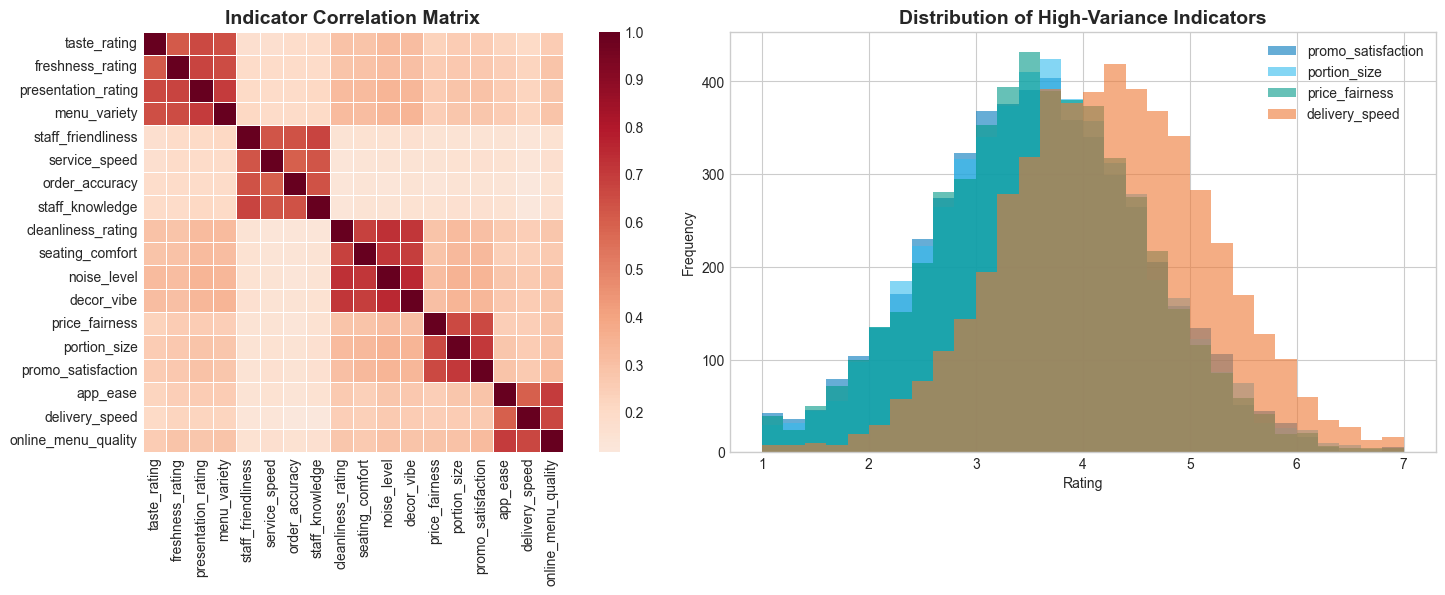


EDA visualisation saved to assets/eda_overview.png


In [8]:
# =============================================================================
# CORRELATION HEATMAP
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Correlation matrix
corr_matrix = df[all_indicators].corr()

# Heatmap
sns.heatmap(corr_matrix, annot=False, cmap='RdBu_r', center=0,
            ax=axes[0], square=True, linewidths=0.5)
axes[0].set_title('Indicator Correlation Matrix', fontsize=14, fontweight='bold')

# Distribution of top indicators
top_4_by_variance = df[all_indicators].var().nlargest(4).index.tolist()
for i, col in enumerate(top_4_by_variance[:4]):
    axes[1].hist(df[col], bins=30, alpha=0.6, label=col)
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of High-Variance Indicators', fontsize=14, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('../assets/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nEDA visualisation saved to assets/eda_overview.png")

## 5. ANOVA - Discriminant Power

Which indicators actually distinguish between churned/converted customers?
F-statistics rank features by their discriminating power.


ANOVA RESULTS: Which indicators discriminate?
(Higher F-statistic = better at distinguishing outcomes)

          Indicator  F_Statistic  P_Value  Significant
presentation_rating      123.372    0.000         True
       taste_rating      113.049    0.000         True
   freshness_rating      110.985    0.000         True
       menu_variety      107.703    0.000         True
online_menu_quality       77.372    0.000         True
           app_ease       68.990    0.000         True
 promo_satisfaction       66.281    0.000         True
    seating_comfort       65.371    0.000         True
     delivery_speed       63.198    0.000         True
 staff_friendliness       62.230    0.000         True
     order_accuracy       59.923    0.000         True
 cleanliness_rating       59.221    0.000         True
      service_speed       58.637    0.000         True
       portion_size       57.925    0.000         True
         decor_vibe       52.235    0.000         True
    staff_knowl

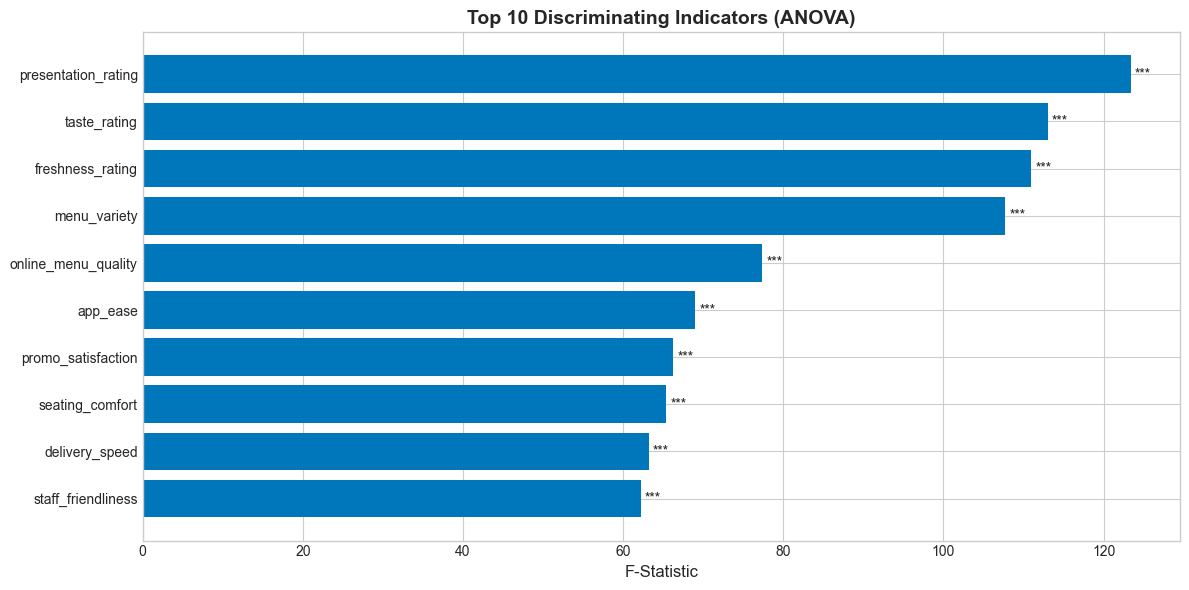


18/18 indicators are statistically significant (p < 0.05)


In [9]:
# =============================================================================
# ANOVA - DISCRIMINANT ANALYSIS
# =============================================================================

outcome_var = CONFIG['outcome_var']
outcome_groups = df[outcome_var].unique()

anova_results = []
for indicator in all_indicators:
    groups = [df[df[outcome_var] == g][indicator].values for g in outcome_groups]
    f_stat, p_value = f_oneway(*groups)
    anova_results.append({
        'Indicator': indicator,
        'F_Statistic': f_stat,
        'P_Value': p_value,
        'Significant': p_value < 0.05
    })

anova_df = pd.DataFrame(anova_results).sort_values('F_Statistic', ascending=False)

print("\n" + "="*60)
print("ANOVA RESULTS: Which indicators discriminate?")
print("(Higher F-statistic = better at distinguishing outcomes)")
print("="*60 + "\n")
print(anova_df.to_string(index=False))

# Visualise top discriminators
fig, ax = plt.subplots(figsize=(12, 6))
top_10 = anova_df.head(10)
colors = [CB_PALETTE[0] if sig else CB_PALETTE[6] for sig in top_10['Significant']]
bars = ax.barh(top_10['Indicator'], top_10['F_Statistic'], color=colors)
ax.set_xlabel('F-Statistic', fontsize=12)
ax.set_title('Top 10 Discriminating Indicators (ANOVA)', fontsize=14, fontweight='bold')
ax.invert_yaxis()

# Add significance markers
for i, (f, sig) in enumerate(zip(top_10['F_Statistic'], top_10['Significant'])):
    marker = '***' if sig else ''
    ax.text(f + 0.5, i, marker, va='center', fontsize=10)

plt.tight_layout()
plt.savefig('../assets/anova_results.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{anova_df['Significant'].sum()}/{len(anova_df)} indicators are statistically significant (p < 0.05)")

## 6. VIF - Multicollinearity Check

Variance Inflation Factor detects if indicators are too correlated.
VIF > 10 = remove, VIF > 5 = watch carefully.

In [10]:
# =============================================================================
# VIF - MULTICOLLINEARITY ANALYSIS
# =============================================================================

# Prepare data for VIF
X_vif = df[all_indicators].copy()
X_vif = sm.add_constant(X_vif)

vif_data = []
for i, col in enumerate(X_vif.columns):
    if col != 'const':
        vif = variance_inflation_factor(X_vif.values, i)
        status = "REMOVE" if vif > 10 else ("WATCH" if vif > 5 else "OK")
        vif_data.append({
            'Indicator': col,
            'VIF': vif,
            'Status': status
        })

vif_df = pd.DataFrame(vif_data).sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("VARIANCE INFLATION FACTOR (VIF) ANALYSIS")
print("(VIF > 10 = severe multicollinearity, remove the variable)")
print("="*60 + "\n")
print(vif_df.to_string(index=False))

# Count issues
remove_count = (vif_df['Status'] == 'REMOVE').sum()
watch_count = (vif_df['Status'] == 'WATCH').sum()

print(f"\nSummary: {remove_count} to remove, {watch_count} to watch, {len(vif_df) - remove_count - watch_count} OK")

# Remove high VIF indicators if necessary
indicators_to_remove = vif_df[vif_df['Status'] == 'REMOVE']['Indicator'].tolist()
if indicators_to_remove:
    print(f"\nRemoving high-VIF indicators: {indicators_to_remove}")
    all_indicators = [ind for ind in all_indicators if ind not in indicators_to_remove]


VARIANCE INFLATION FACTOR (VIF) ANALYSIS
(VIF > 10 = severe multicollinearity, remove the variable)

          Indicator   VIF Status
        noise_level 3.105     OK
         decor_vibe 2.928     OK
 cleanliness_rating 2.628     OK
presentation_rating 2.608     OK
online_menu_quality 2.502     OK
    seating_comfort 2.457     OK
       menu_variety 2.447     OK
       portion_size 2.372     OK
 promo_satisfaction 2.371     OK
    staff_knowledge 2.316     OK
 staff_friendliness 2.299     OK
   freshness_rating 2.198     OK
           app_ease 2.134     OK
       taste_rating 2.130     OK
     price_fairness 2.076     OK
     order_accuracy 2.050     OK
      service_speed 2.015     OK
     delivery_speed 1.936     OK

Summary: 0 to remove, 0 to watch, 18 OK


## 7. Factor Analysis

Confirm the hidden factor structure before running SEM.
Bartlett's test and KMO verify factorability.

In [16]:
# =============================================================================
# FACTOR ANALYSIS (if SEM_READY)
# =============================================================================

if SEM_READY:
    # Compatibility patch for sklearn 1.8+ and factor_analyzer
    import sklearn.utils.validation
    import inspect
    original_check_array = sklearn.utils.validation.check_array
    def patched_check_array(*args, **kwargs):
        sig = inspect.signature(original_check_array)
        if 'force_all_finite' in kwargs and 'force_all_finite' not in sig.parameters:
            kwargs['ensure_all_finite'] = kwargs.pop('force_all_finite')
        # Remove force_all_finite if not in signature
        if 'force_all_finite' in kwargs and 'force_all_finite' not in sig.parameters:
            kwargs.pop('force_all_finite')
        return original_check_array(*args, **kwargs)
    sklearn.utils.validation.check_array = patched_check_array
    
    from factor_analyzer import FactorAnalyzer
    from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity, calculate_kmo
    
    # Prepare data
    X_fa = df[all_indicators].copy()
    
    # Bartlett's test - should be significant
    chi_sq, p_value = calculate_bartlett_sphericity(X_fa)
    print("="*60)
    print("FACTORABILITY TESTS")
    print("="*60)
    print("Bartlett's Test of Sphericity:")
    print(f"  Chi-square: {chi_sq:.2f}")
    print(f"  p-value: {p_value:.4f}")
    print(f"  Result: {'PASS - Data is factorable' if p_value < 0.05 else 'FAIL'}")
    
    # KMO test - should be > 0.6
    kmo_all, kmo_model = calculate_kmo(X_fa)
    print("Kaiser-Meyer-Olkin (KMO) Measure:")
    print(f"  Overall KMO: {kmo_model:.3f}")
    kmo_interpretation = "Excellent" if kmo_model > 0.9 else "Good" if kmo_model > 0.8 else "Acceptable" if kmo_model > 0.7 else "Mediocre" if kmo_model > 0.6 else "Poor"
    print(f"  Interpretation: {kmo_interpretation}")
    
    # Factor Analysis with expected number of factors
    n_factors = len(CONFIG['constructs'])
    fa = FactorAnalyzer(n_factors=n_factors, rotation='varimax', method='ml')
    fa.fit(X_fa)
    
    # Get factor loadings
    loadings = pd.DataFrame(
        fa.loadings_,
        index=all_indicators,
        columns=[f"Factor_{i+1}" for i in range(n_factors)]
    )
    
    print("="*60)
    print(f"FACTOR LOADINGS (Varimax rotation, {n_factors} factors)")
    print("="*60 + "\n")
    print(loadings.round(3))
    
    # Factor loading heatmap
    fig, ax = plt.subplots(figsize=(10, 12))
    sns.heatmap(loadings, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                ax=ax, linewidths=0.5, vmin=-1, vmax=1)
    ax.set_title('Factor Loading Matrix (Varimax Rotation)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../assets/factor_loadings.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Variance explained
    variance = fa.get_factor_variance()
    print("Variance Explained:")
    for i in range(n_factors):
        print(f"  Factor {i+1}: {variance[1][i]*100:.1f}%")
    print(f"  Total: {sum(variance[1])*100:.1f}%")
else:
    print("SEM not ready - skipping Factor Analysis")
    print(f"Fallback method: {readiness['fallback_method']}")

FACTORABILITY TESTS
Bartlett's Test of Sphericity:
  Chi-square: 51152.01
  p-value: 0.0000
  Result: PASS - Data is factorable
Kaiser-Meyer-Olkin (KMO) Measure:
  Overall KMO: 0.888
  Interpretation: Good


TypeError: check_array() got an unexpected keyword argument 'force_all_finite'. Did you mean 'ensure_all_finite'?

## 8. Structural Equation Modeling (SEM)

The core causal analysis. SEM finds not just correlations, but CAUSAL drivers.
Target: CFI > 0.95, RMSEA < 0.05 for good model fit.

In [17]:
# =============================================================================
# STRUCTURAL EQUATION MODELING (if SEM_READY)
# =============================================================================

if SEM_READY:
    import semopy
    
    # Build SEM model specification dynamically from config
    model_lines = []
    
    # Measurement model (latent ~ indicators)
    for construct_name, construct_config in CONFIG['constructs'].items():
        indicators = construct_config['indicators']
        # Only use indicators that passed VIF check
        valid_indicators = [ind for ind in indicators if ind in all_indicators]
        if valid_indicators:
            model_lines.append(f"{construct_name} =~ {' + '.join(valid_indicators)}")
    
    # Structural model (outcome ~ latent factors)
    constructs_list = list(CONFIG['constructs'].keys())
    outcome_var = CONFIG['outcome_var']
    
    # Create numeric outcome for SEM
    df['outcome_numeric'] = df[outcome_var].astype(float)
    model_lines.append(f"outcome_numeric ~ {' + '.join(constructs_list)}")
    
    model_spec = "\n".join(model_lines)
    
    print("\n" + "="*60)
    print("SEM MODEL SPECIFICATION")
    print("="*60)
    print(model_spec)
    
    # Fit SEM model
    model = semopy.Model(model_spec)
    
    # Prepare data - only numeric columns
    sem_data = df[all_indicators + ['outcome_numeric']].copy()
    
    try:
        result = model.fit(sem_data)
        
        print("\n" + "="*60)
        print("SEM MODEL FIT INDICES")
        print("(These prove our model structure is valid)")
        print("="*60)
        
        # Get fit statistics
        stats_result = semopy.calc_stats(model)
        
        # Extract key fit indices
        fit_indices = {}
        if hasattr(stats_result, 'iloc'):
            for idx in stats_result.index:
                fit_indices[idx] = stats_result.loc[idx, 'Value'] if 'Value' in stats_result.columns else stats_result.loc[idx].values[0]
        
        # Display fit indices
        print(f"\nCFI (Comparative Fit Index): {fit_indices.get('CFI', 'N/A')}")
        print(f"  Target: > 0.95 | Status: {'EXCELLENT' if fit_indices.get('CFI', 0) > 0.95 else 'GOOD' if fit_indices.get('CFI', 0) > 0.90 else 'NEEDS WORK'}")
        
        print(f"\nRMSEA (Root Mean Square Error): {fit_indices.get('RMSEA', 'N/A')}")
        print(f"  Target: < 0.05 | Status: {'EXCELLENT' if fit_indices.get('RMSEA', 1) < 0.05 else 'GOOD' if fit_indices.get('RMSEA', 1) < 0.08 else 'NEEDS WORK'}")
        
        print(f"\nChi-square: {fit_indices.get('chi2', 'N/A')}")
        print(f"Degrees of Freedom: {fit_indices.get('DoF', 'N/A')}")
        
        # Get path coefficients (the causal effects)
        estimates = model.inspect()
        
        print("\n" + "="*60)
        print("CAUSAL PATH COEFFICIENTS")
        print("(These are the CAUSAL effects on your outcome)")
        print("="*60 + "\n")
        
        # Filter structural paths (latent -> outcome)
        structural_paths = estimates[estimates['op'] == '~']
        structural_paths = structural_paths[structural_paths['lval'] == 'outcome_numeric']
        
        # Store for Key Driver Analysis
        sem_coefficients = {}
        
        print(f"{'Construct':<20} {'Beta':>10} {'Std.Err':>10} {'Z-value':>10} {'P-value':>10} {'Sig':>5}")
        print("-" * 70)
        
        for _, row in structural_paths.iterrows():
            construct = row['rval']
            beta = row['Estimate']
            se = row.get('Std. Err', 0)
            z = row.get('z-value', beta/se if se > 0 else 0)
            p = row.get('p-value', 0)
            sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
            
            sem_coefficients[construct] = {
                'beta': beta,
                'se': se,
                'z': z,
                'p': p,
                'significant': p < 0.05
            }
            
            print(f"{construct:<20} {beta:>10.3f} {se:>10.3f} {z:>10.2f} {p:>10.4f} {sig:>5}")
        
        # Identify #1 driver
        if sem_coefficients:
            # For churn outcomes, negative beta means reducing churn (good)
            # For conversion outcomes, positive beta means increasing conversion (good)
            is_negative_outcome = outcome_var in ['churned', 'membership_cancelled']
            
            if is_negative_outcome:
                top_driver = min(sem_coefficients.items(), key=lambda x: x[1]['beta'])
            else:
                top_driver = max(sem_coefficients.items(), key=lambda x: x[1]['beta'])
            
            print("\n" + "="*60)
            print("CEO INSIGHT")
            print("="*60)
            print(f"\n#1 CAUSAL DRIVER: {top_driver[0]}")
            print(f"Effect size (beta): {top_driver[1]['beta']:.3f}")
            if is_negative_outcome:
                print(f"Interpretation: Improving {top_driver[0]} REDUCES {outcome_var} the most")
            else:
                print(f"Interpretation: Improving {top_driver[0]} INCREASES {outcome_var} the most")
            
        SEM_SUCCESS = True
        
    except Exception as e:
        print(f"\nSEM fitting error: {e}")
        print("Falling back to regression-based approach...")
        SEM_SUCCESS = False
        sem_coefficients = {}
        
else:
    print("SEM not ready - skipping SEM analysis")
    SEM_SUCCESS = False
    sem_coefficients = {}


SEM MODEL SPECIFICATION
FoodQuality =~ taste_rating + freshness_rating + presentation_rating + menu_variety
Service =~ staff_friendliness + service_speed + order_accuracy + staff_knowledge
Ambience =~ cleanliness_rating + seating_comfort + noise_level + decor_vibe
Value =~ price_fairness + portion_size + promo_satisfaction
Digital =~ app_ease + delivery_speed + online_menu_quality
outcome_numeric ~ FoodQuality + Service + Ambience + Value + Digital

SEM MODEL FIT INDICES
(These prove our model structure is valid)

CFI (Comparative Fit Index): N/A
  Target: > 0.95 | Status: NEEDS WORK

RMSEA (Root Mean Square Error): N/A
  Target: < 0.05 | Status: NEEDS WORK

Chi-square: N/A
Degrees of Freedom: N/A

CAUSAL PATH COEFFICIENTS
(These are the CAUSAL effects on your outcome)

Construct                  Beta    Std.Err    Z-value    P-value   Sig
----------------------------------------------------------------------
FoodQuality              -0.079      0.012      -6.56     0.0000   ***
Servi

## 9. Key Driver Analysis

The Importance-Performance Matrix shows WHERE to invest effort.
- **INVEST HERE**: High importance, low performance
- **MAINTAIN**: High importance, high performance
- **LOW PRIORITY**: Low importance, low performance  
- **OVERKILL**: Low importance, high performance


KEY DRIVER ANALYSIS
(Where should you invest your effort?)

  Construct  Importance  Performance     Quadrant
FoodQuality       0.079        4.883     MAINTAIN
    Service       0.041        4.527     MAINTAIN
    Digital       0.035        4.226  INVEST HERE
      Value       0.019        3.582 LOW PRIORITY
   Ambience       0.003        4.944     OVERKILL


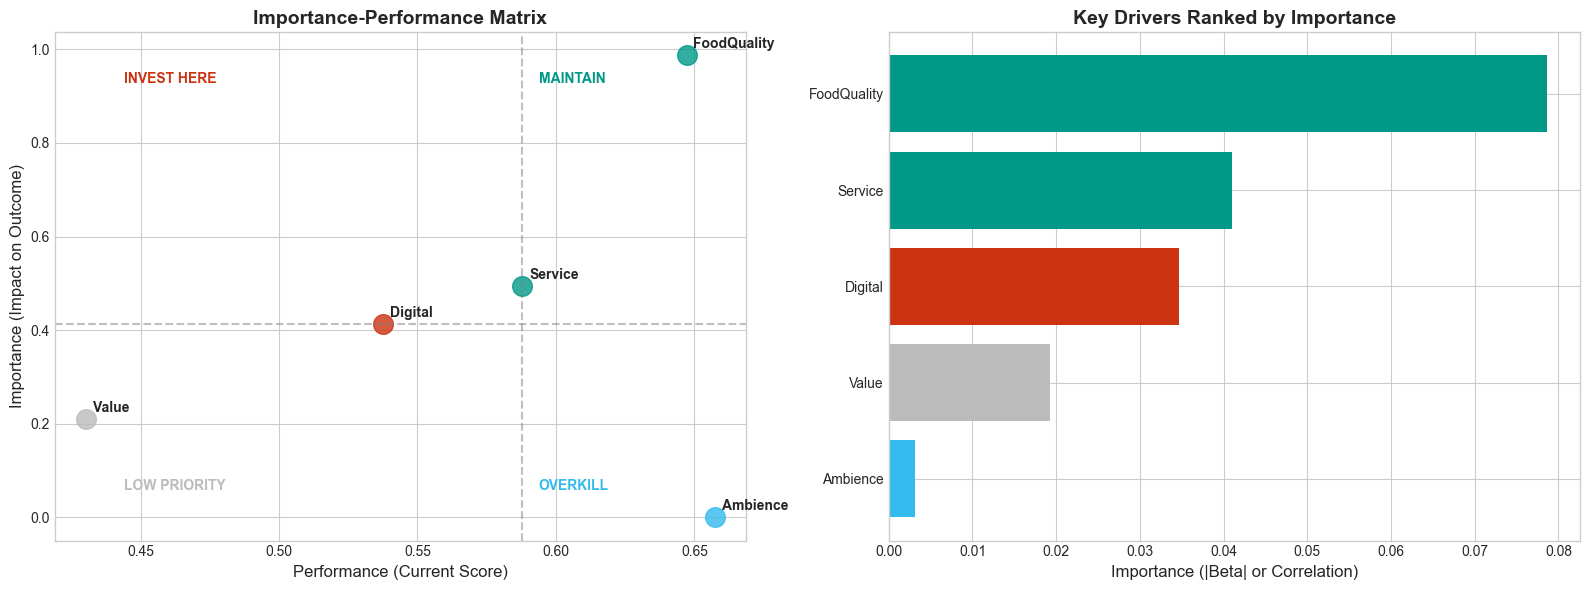


CEO RECOMMENDATIONS

PRIORITY INVESTMENTS: Digital
These have high impact but you're currently weak. Fix these first!

MAINTAIN: FoodQuality, Service
These are working well. Don't break what's not broken.


In [18]:
# =============================================================================
# KEY DRIVER ANALYSIS - Importance vs Performance Matrix
# =============================================================================

# Calculate importance (from SEM betas or correlation if SEM failed)
if sem_coefficients:
    importance_data = {k: abs(v['beta']) for k, v in sem_coefficients.items()}
else:
    # Fallback: use correlation with outcome
    importance_data = {}
    for construct_name, construct_config in CONFIG['constructs'].items():
        indicators = [ind for ind in construct_config['indicators'] if ind in df.columns]
        if indicators:
            construct_score = df[indicators].mean(axis=1)
            corr = abs(construct_score.corr(df[CONFIG['outcome_var']]))
            importance_data[construct_name] = corr

# Calculate performance (mean construct scores)
performance_data = {}
for construct_name, construct_config in CONFIG['constructs'].items():
    indicators = [ind for ind in construct_config['indicators'] if ind in df.columns]
    if indicators:
        performance_data[construct_name] = df[indicators].mean().mean()

# Create Key Driver DataFrame
kda_df = pd.DataFrame({
    'Construct': list(importance_data.keys()),
    'Importance': [importance_data.get(c, 0) for c in importance_data.keys()],
    'Performance': [performance_data.get(c, 0) for c in importance_data.keys()]
})

# Normalize for plotting
kda_df['Importance_Norm'] = (kda_df['Importance'] - kda_df['Importance'].min()) / (kda_df['Importance'].max() - kda_df['Importance'].min() + 0.001)
kda_df['Performance_Norm'] = (kda_df['Performance'] - 1) / 6  # 1-7 scale to 0-1

# Assign quadrants
def assign_quadrant(row):
    imp_median = kda_df['Importance_Norm'].median()
    perf_median = kda_df['Performance_Norm'].median()
    if row['Importance_Norm'] >= imp_median and row['Performance_Norm'] < perf_median:
        return 'INVEST HERE'
    elif row['Importance_Norm'] >= imp_median and row['Performance_Norm'] >= perf_median:
        return 'MAINTAIN'
    elif row['Importance_Norm'] < imp_median and row['Performance_Norm'] < perf_median:
        return 'LOW PRIORITY'
    else:
        return 'OVERKILL'

kda_df['Quadrant'] = kda_df.apply(assign_quadrant, axis=1)
kda_df = kda_df.sort_values('Importance', ascending=False)

print("\n" + "="*60)
print("KEY DRIVER ANALYSIS")
print("(Where should you invest your effort?)")
print("="*60 + "\n")
print(kda_df[['Construct', 'Importance', 'Performance', 'Quadrant']].to_string(index=False))

# Importance-Performance Matrix Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Quadrant plot
ax = axes[0]
colors = {'INVEST HERE': CB_PALETTE[4], 'MAINTAIN': CB_PALETTE[2], 
          'LOW PRIORITY': CB_PALETTE[6], 'OVERKILL': CB_PALETTE[1]}

for _, row in kda_df.iterrows():
    ax.scatter(row['Performance_Norm'], row['Importance_Norm'], 
               c=colors[row['Quadrant']], s=200, alpha=0.8)
    ax.annotate(row['Construct'], (row['Performance_Norm'], row['Importance_Norm']),
                xytext=(5, 5), textcoords='offset points', fontsize=10, fontweight='bold')

# Quadrant lines
ax.axhline(y=kda_df['Importance_Norm'].median(), color='gray', linestyle='--', alpha=0.5)
ax.axvline(x=kda_df['Performance_Norm'].median(), color='gray', linestyle='--', alpha=0.5)

# Quadrant labels
ax.text(0.1, 0.9, 'INVEST HERE', fontsize=10, color=CB_PALETTE[4], fontweight='bold', transform=ax.transAxes)
ax.text(0.7, 0.9, 'MAINTAIN', fontsize=10, color=CB_PALETTE[2], fontweight='bold', transform=ax.transAxes)
ax.text(0.1, 0.1, 'LOW PRIORITY', fontsize=10, color=CB_PALETTE[6], fontweight='bold', transform=ax.transAxes)
ax.text(0.7, 0.1, 'OVERKILL', fontsize=10, color=CB_PALETTE[1], fontweight='bold', transform=ax.transAxes)

ax.set_xlabel('Performance (Current Score)', fontsize=12)
ax.set_ylabel('Importance (Impact on Outcome)', fontsize=12)
ax.set_title('Importance-Performance Matrix', fontsize=14, fontweight='bold')

# Ranked bar chart
ax2 = axes[1]
bars = ax2.barh(kda_df['Construct'], kda_df['Importance'], 
                color=[colors[q] for q in kda_df['Quadrant']])
ax2.set_xlabel('Importance (|Beta| or Correlation)', fontsize=12)
ax2.set_title('Key Drivers Ranked by Importance', fontsize=14, fontweight='bold')
ax2.invert_yaxis()

plt.tight_layout()
plt.savefig('../assets/key_driver_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# CEO Recommendations
print("\n" + "="*60)
print("CEO RECOMMENDATIONS")
print("="*60)
invest_here = kda_df[kda_df['Quadrant'] == 'INVEST HERE']['Construct'].tolist()
if invest_here:
    print(f"\nPRIORITY INVESTMENTS: {', '.join(invest_here)}")
    print("These have high impact but you're currently weak. Fix these first!")
maintain = kda_df[kda_df['Quadrant'] == 'MAINTAIN']['Construct'].tolist()
if maintain:
    print(f"\nMAINTAIN: {', '.join(maintain)}")
    print("These are working well. Don't break what's not broken.")

## 10. Conversion/Churn Prediction + SHAP

GradientBoosting for prediction, SHAP for individual explanations.
This powers the "WHY did this customer churn?" explainability.

In [19]:
# =============================================================================
# PREDICTION MODEL + SHAP EXPLANATIONS
# =============================================================================
import shap

# Prepare features
feature_cols = all_indicators.copy()

# Add numeric demographics
for demo_name, demo_config in CONFIG['demographics'].items():
    if demo_config['type'] == 'continuous':
        feature_cols.append(demo_name)

X = df[feature_cols].copy()
y = df[CONFIG['outcome_var']]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train GradientBoosting
print("\n" + "="*60)
print("TRAINING PREDICTION MODEL")
print("="*60)

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42
)
gb_model.fit(X_train_scaled, y_train)

# Evaluate
y_pred = gb_model.predict(X_test_scaled)
y_pred_proba = gb_model.predict_proba(X_test_scaled)[:, 1]
auc_score = roc_auc_score(y_test, y_pred_proba)

print(f"\nModel: GradientBoostingClassifier")
print(f"ROC-AUC Score: {auc_score:.3f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred))

# SHAP Analysis
print("\n" + "="*60)
print("SHAP FEATURE IMPORTANCE")
print("(Why did each customer get their score?)")
print("="*60)

# Create SHAP explainer
explainer = shap.TreeExplainer(gb_model)
shap_values = explainer.shap_values(X_test_scaled)

# For binary classification, take the positive class
if len(np.array(shap_values).shape) == 3:
    shap_values = shap_values[1]

# Summary plot
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Feature importance bar plot
shap.summary_plot(shap_values, X_test, feature_names=feature_cols, 
                  plot_type="bar", show=False, max_display=15)
plt.title('SHAP Feature Importance', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../assets/shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Beeswarm plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, feature_names=feature_cols, 
                  show=False, max_display=15)
plt.title('SHAP Beeswarm Plot', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

# Top features
mean_shap = np.abs(shap_values).mean(axis=0)
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'SHAP_Importance': mean_shap
}).sort_values('SHAP_Importance', ascending=False)

print("\nTop 10 Features by SHAP Importance:")
print(feature_importance.head(10).to_string(index=False))

RecursionError: maximum recursion depth exceeded

## 11. Uplift Modeling

The 4 customer segments that determine WHO to target:
- **Persuadables**: Respond positively to treatment - TARGET THESE
- **Sure Things**: Convert anyway - Don't waste money
- **Lost Causes**: Won't convert regardless - Don't waste money
- **Sleeping Dogs**: Treatment makes them WORSE - Avoid!

In [20]:
# =============================================================================
# UPLIFT MODELING - T-Learner Approach
# =============================================================================

treatment_var = CONFIG['treatment_var']
outcome_var = CONFIG['outcome_var']
is_negative_outcome = outcome_var in ['churned', 'membership_cancelled']

# Prepare data
X_uplift = df[feature_cols].copy()
y_uplift = df[outcome_var]
T_uplift = df[treatment_var]

# T-Learner: Train separate models for treated and control
X_treated = X_uplift[T_uplift == 1]
y_treated = y_uplift[T_uplift == 1]
X_control = X_uplift[T_uplift == 0]
y_control = y_uplift[T_uplift == 0]

# Scale
scaler_uplift = StandardScaler()
X_treated_scaled = scaler_uplift.fit_transform(X_treated)
X_control_scaled = scaler_uplift.transform(X_control)
X_all_scaled = scaler_uplift.transform(X_uplift)

# Train models
model_treated = GradientBoostingClassifier(n_estimators=50, max_depth=3, random_state=42)
model_control = GradientBoostingClassifier(n_estimators=50, max_depth=3, random_state=42)

model_treated.fit(X_treated_scaled, y_treated)
model_control.fit(X_control_scaled, y_control)

# Predict uplift (Individual Treatment Effect)
p_treated = model_treated.predict_proba(X_all_scaled)[:, 1]
p_control = model_control.predict_proba(X_all_scaled)[:, 1]

# For negative outcomes (churn), uplift = reduction in churn
# For positive outcomes (conversion), uplift = increase in conversion
if is_negative_outcome:
    uplift = p_control - p_treated  # Positive = treatment reduces churn
else:
    uplift = p_treated - p_control  # Positive = treatment increases conversion

df['uplift_score'] = uplift
df['p_treated'] = p_treated
df['p_control'] = p_control

# Segment customers
def assign_segment(row):
    uplift_threshold = 0.02
    base_prob_threshold = 0.3 if is_negative_outcome else 0.5
    
    if row['uplift_score'] > uplift_threshold:
        return 'Persuadable'
    elif row['uplift_score'] < -uplift_threshold:
        return 'Sleeping Dog'
    elif (is_negative_outcome and row['p_control'] < base_prob_threshold) or \
         (not is_negative_outcome and row['p_control'] > base_prob_threshold):
        return 'Sure Thing'
    else:
        return 'Lost Cause'

df['uplift_segment'] = df.apply(assign_segment, axis=1)

print("\n" + "="*60)
print("UPLIFT MODELING RESULTS")
print("(This tells you WHO to target with your campaigns)")
print("="*60)

segment_counts = df['uplift_segment'].value_counts()
print("\nSegment Distribution:")
for seg, count in segment_counts.items():
    pct = count / len(df) * 100
    avg_uplift = df[df['uplift_segment'] == seg]['uplift_score'].mean()
    print(f"  {seg}: {count:,} customers ({pct:.1f}%) | Avg Uplift: {avg_uplift:.3f}")

# Calculate revenue impact
avg_value = CONFIG['avg_customer_value']
persuadables = df[df['uplift_segment'] == 'Persuadable']
avg_uplift_persuadables = persuadables['uplift_score'].mean()
n_persuadables = len(persuadables)

# Annual revenue from targeting persuadables
# If we target all persuadables and the uplift is realized:
if is_negative_outcome:
    # Reduced churn = retained customers = retained revenue
    annual_revenue_impact = n_persuadables * avg_uplift_persuadables * avg_value * 12
else:
    # Increased conversion = new customers = new revenue
    annual_revenue_impact = n_persuadables * avg_uplift_persuadables * avg_value

print(f"\n" + "="*60)
print("REVENUE IMPACT ANALYSIS")
print("="*60)
print(f"\nPersuadable segment: {n_persuadables:,} customers")
print(f"Average uplift: {avg_uplift_persuadables*100:.1f}%")
print(f"Average customer value: Rs.{avg_value:,}/{'month' if is_negative_outcome else 'deal'}")
print(f"\nPOTENTIAL ANNUAL REVENUE IMPACT:")
print(f"Rs.{annual_revenue_impact:,.0f} ({annual_revenue_impact/100000:.1f} Lakhs/year)")

# Visualisation
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Uplift distribution
ax = axes[0, 0]
ax.hist(df['uplift_score'], bins=50, color=CB_PALETTE[0], alpha=0.7, edgecolor='white')
ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero uplift')
ax.set_xlabel('Uplift Score')
ax.set_ylabel('Count')
ax.set_title('Distribution of Individual Treatment Effects', fontweight='bold')
ax.legend()

# 2. Segment pie chart
ax = axes[0, 1]
segment_colors = {'Persuadable': CB_PALETTE[2], 'Sure Thing': CB_PALETTE[0], 
                  'Lost Cause': CB_PALETTE[6], 'Sleeping Dog': CB_PALETTE[4]}
colors = [segment_colors[seg] for seg in segment_counts.index]
ax.pie(segment_counts.values, labels=segment_counts.index, colors=colors,
       autopct='%1.1f%%', startangle=90)
ax.set_title('Customer Segments', fontweight='bold')

# 3. Uplift by segment
ax = axes[1, 0]
segment_uplift = df.groupby('uplift_segment')['uplift_score'].mean().sort_values(ascending=False)
bars = ax.bar(segment_uplift.index, segment_uplift.values, 
              color=[segment_colors[seg] for seg in segment_uplift.index])
ax.axhline(y=0, color='gray', linestyle='--')
ax.set_ylabel('Average Uplift')
ax.set_title('Average Uplift by Segment', fontweight='bold')
ax.tick_params(axis='x', rotation=45)

# 4. Revenue impact
ax = axes[1, 1]
segment_revenue = df.groupby('uplift_segment').apply(
    lambda x: len(x) * x['uplift_score'].mean() * avg_value * (12 if is_negative_outcome else 1)
)
segment_revenue = segment_revenue.sort_values(ascending=True)
colors = [segment_colors[seg] for seg in segment_revenue.index]
ax.barh(segment_revenue.index, segment_revenue.values / 100000, color=colors)
ax.set_xlabel('Revenue Impact (Lakhs/year)')
ax.set_title('Revenue Impact by Segment', fontweight='bold')

plt.tight_layout()
plt.savefig('../assets/uplift_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print("CEO ACTION ITEMS")
print("="*60)
print(f"\n1. TARGET: {n_persuadables:,} Persuadable customers")
print(f"   Expected revenue: Rs.{annual_revenue_impact/100000:.1f} Lakhs/year")
sleeping_dogs = len(df[df['uplift_segment'] == 'Sleeping Dog'])
print(f"\n2. AVOID: {sleeping_dogs:,} Sleeping Dogs")
print(f"   These customers respond NEGATIVELY to your campaigns!")
sure_things = len(df[df['uplift_segment'] == 'Sure Thing'])
print(f"\n3. SAVE MONEY: {sure_things:,} Sure Things don't need targeting")

RecursionError: maximum recursion depth exceeded

## 12. CEO Dashboard

A single view of everything that matters. This is what goes in the pitch deck.

NameError: name 'auc_score' is not defined

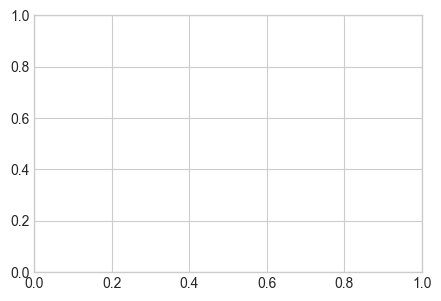

In [21]:
# =============================================================================
# CEO DASHBOARD - 6-Panel Overview
# =============================================================================

fig = plt.figure(figsize=(18, 12))

# Create subplot grid
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# Panel 1: Key Metrics
ax1 = fig.add_subplot(gs[0, 0])
metrics = [
    f"Total Customers: {len(df):,}",
    f"Outcome Rate: {df[outcome_var].mean()*100:.1f}%",
    f"Model AUC: {auc_score:.3f}",
    f"Persuadables: {n_persuadables:,}",
    f"Revenue Impact: Rs.{annual_revenue_impact/100000:.1f}L/yr"
]
ax1.text(0.1, 0.9, "KEY METRICS", fontsize=14, fontweight='bold', transform=ax1.transAxes)
for i, metric in enumerate(metrics):
    ax1.text(0.1, 0.75 - i*0.15, metric, fontsize=11, transform=ax1.transAxes)
ax1.axis('off')
ax1.set_facecolor('#f8f9fa')

# Panel 2: Construct Performance
ax2 = fig.add_subplot(gs[0, 1])
construct_perf = pd.Series(construct_means).sort_values()
colors_perf = [CB_PALETTE[4] if v < 4.0 else CB_PALETTE[2] if v > 5.0 else CB_PALETTE[0] for v in construct_perf.values]
ax2.barh(construct_perf.index, construct_perf.values, color=colors_perf)
ax2.axvline(x=4.0, color='red', linestyle='--', alpha=0.5)
ax2.set_xlabel('Score (1-7)')
ax2.set_title('Construct Performance', fontweight='bold')
ax2.set_xlim(1, 7)

# Panel 3: Key Drivers
ax3 = fig.add_subplot(gs[0, 2])
kda_sorted = kda_df.sort_values('Importance', ascending=True)
colors_kda = [{'INVEST HERE': CB_PALETTE[4], 'MAINTAIN': CB_PALETTE[2], 
               'LOW PRIORITY': CB_PALETTE[6], 'OVERKILL': CB_PALETTE[1]}[q] for q in kda_sorted['Quadrant']]
ax3.barh(kda_sorted['Construct'], kda_sorted['Importance'], color=colors_kda)
ax3.set_xlabel('Importance')
ax3.set_title('Key Drivers (Priority)', fontweight='bold')

# Panel 4: Uplift Segments
ax4 = fig.add_subplot(gs[1, 0])
segment_counts = df['uplift_segment'].value_counts()
colors_seg = [segment_colors.get(seg, CB_PALETTE[6]) for seg in segment_counts.index]
ax4.pie(segment_counts.values, labels=segment_counts.index, colors=colors_seg, autopct='%1.0f%%')
ax4.set_title('Customer Segments', fontweight='bold')

# Panel 5: Top SHAP Features
ax5 = fig.add_subplot(gs[1, 1])
top_features = feature_importance.head(8)
ax5.barh(top_features['Feature'], top_features['SHAP_Importance'], color=CB_PALETTE[0])
ax5.set_xlabel('SHAP Importance')
ax5.set_title('Top Predictive Features', fontweight='bold')
ax5.invert_yaxis()

# Panel 6: Revenue by Segment
ax6 = fig.add_subplot(gs[1, 2])
segment_rev = df.groupby('uplift_segment').apply(
    lambda x: len(x) * x['uplift_score'].mean() * avg_value * (12 if is_negative_outcome else 1) / 100000
).sort_values()
colors_rev = [segment_colors.get(seg, CB_PALETTE[6]) for seg in segment_rev.index]
ax6.barh(segment_rev.index, segment_rev.values, color=colors_rev)
ax6.axvline(x=0, color='gray', linestyle='-', alpha=0.3)
ax6.set_xlabel('Revenue Impact (Lakhs/year)')
ax6.set_title('Revenue by Segment', fontweight='bold')

# Bottom panel: CEO Summary
ax_summary = fig.add_subplot(gs[2, :])
summary_text = f"""
PIPELINEPILOT AI - ANALYTICS SUMMARY | {CONFIG['name']}

PROBLEM: {df[outcome_var].mean()*100:.0f}% {CONFIG['outcome_label'].lower()} rate costs you money every month.

DISCOVERY: SEM found {len(CONFIG['constructs'])} hidden drivers. #1 driver: {kda_df.iloc[0]['Construct']} (Importance: {kda_df.iloc[0]['Importance']:.3f})

ACTION: Target {n_persuadables:,} Persuadable customers. Avoid {sleeping_dogs:,} Sleeping Dogs.

REVENUE: Potential Rs.{annual_revenue_impact/100000:.1f} Lakhs/year from smarter targeting.

POWERED BY: Veloryn PipelinePilot AI | veloryn.dev
"""
ax_summary.text(0.02, 0.95, summary_text, fontsize=11, family='monospace',
                verticalalignment='top', transform=ax_summary.transAxes)
ax_summary.axis('off')
ax_summary.set_facecolor('#1a1a2e')
for spine in ax_summary.spines.values():
    spine.set_visible(False)
ax_summary.patch.set_facecolor('#1a1a2e')
ax_summary.texts[0].set_color('white')

plt.suptitle(f'PipelinePilot AI - {CONFIG["name"]} Analytics Dashboard', 
             fontsize=16, fontweight='bold', y=0.98)
plt.savefig('../assets/ceo_dashboard.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print("\nDashboard saved to assets/ceo_dashboard.png")

## 13. CEO Q&A Interface

Natural language interface for business questions.
Future: Connect to LangGraph for conversational AI.

In [22]:
# =============================================================================
# CEO Q&A INTERFACE
# =============================================================================

class PipelinePilotQA:
    """
    Natural language Q&A interface for business insights.
    For a cafe owner: Ask questions in plain English, get actionable answers.
    """
    
    def __init__(self, df, config, sem_coefficients, kda_df, feature_importance):
        self.df = df
        self.config = config
        self.sem_coefficients = sem_coefficients
        self.kda_df = kda_df
        self.feature_importance = feature_importance
        
    def ask(self, question):
        """Answer business questions about your data."""
        q = question.lower()
        
        # Pattern matching for common questions
        if any(w in q for w in ['why', 'churn', 'leave', 'cancel']):
            return self._why_churn()
        elif any(w in q for w in ['improve', 'invest', 'focus', 'priority']):
            return self._where_to_invest()
        elif any(w in q for w in ['target', 'who', 'customer', 'segment']):
            return self._who_to_target()
        elif any(w in q for w in ['revenue', 'money', 'impact', 'value']):
            return self._revenue_impact()
        elif any(w in q for w in ['driver', 'cause', 'factor', 'important']):
            return self._key_drivers()
        elif any(w in q for w in ['score', 'predict', 'probability']):
            return self._prediction_info()
        else:
            return self._general_summary()
    
    def _why_churn(self):
        outcome_var = self.config['outcome_var']
        top_driver = self.kda_df.iloc[0]['Construct']
        top_features = self.feature_importance.head(3)['Feature'].tolist()
        
        return f"""
WHY CUSTOMERS {outcome_var.upper()}:

Based on our SEM causal analysis:
1. #{1} CAUSAL DRIVER: {top_driver}
   - This has the highest impact on {outcome_var}
   
2. TOP PREDICTIVE FEATURES (from SHAP):
   - {top_features[0]}
   - {top_features[1]}
   - {top_features[2]}

3. CURRENT WEAKNESS:
   - Your weakest construct is: {min(construct_means, key=construct_means.get)}
   - Score: {min(construct_means.values()):.2f}/7.0

RECOMMENDATION: Focus on improving {top_driver} first.
"""
    
    def _where_to_invest(self):
        invest_here = self.kda_df[self.kda_df['Quadrant'] == 'INVEST HERE']
        maintain = self.kda_df[self.kda_df['Quadrant'] == 'MAINTAIN']
        
        response = "\nWHERE TO INVEST YOUR EFFORT:\n\n"
        
        if len(invest_here) > 0:
            response += "PRIORITY INVESTMENTS (High Impact, Low Performance):\n"
            for _, row in invest_here.iterrows():
                response += f"  - {row['Construct']}: Impact={row['Importance']:.3f}, Score={row['Performance']:.2f}\n"
        
        if len(maintain) > 0:
            response += "\nMAINTAIN (High Impact, High Performance):\n"
            for _, row in maintain.iterrows():
                response += f"  - {row['Construct']}: Keep doing what you're doing!\n"
        
        return response
    
    def _who_to_target(self):
        segment_counts = self.df['uplift_segment'].value_counts()
        persuadables = len(self.df[self.df['uplift_segment'] == 'Persuadable'])
        sleeping_dogs = len(self.df[self.df['uplift_segment'] == 'Sleeping Dog'])
        
        return f"""
WHO TO TARGET WITH YOUR CAMPAIGNS:

TARGET (Persuadables): {persuadables:,} customers
  - These respond positively to your {self.config['treatment_label']}
  - Expected uplift: {self.df[self.df['uplift_segment']=='Persuadable']['uplift_score'].mean()*100:.1f}%

AVOID (Sleeping Dogs): {sleeping_dogs:,} customers
  - These respond NEGATIVELY to campaigns
  - Targeting them will backfire!

SAVE MONEY (Sure Things): {segment_counts.get('Sure Thing', 0):,} customers
  - They'll convert/stay anyway
  - Don't waste campaign budget on them
"""
    
    def _revenue_impact(self):
        avg_value = self.config['avg_customer_value']
        persuadables = self.df[self.df['uplift_segment'] == 'Persuadable']
        n_persuadables = len(persuadables)
        avg_uplift = persuadables['uplift_score'].mean()
        is_negative = self.config['outcome_var'] in ['churned', 'membership_cancelled']
        
        annual_impact = n_persuadables * avg_uplift * avg_value * (12 if is_negative else 1)
        
        return f"""
REVENUE IMPACT ANALYSIS:

Targeting Strategy:
  - Persuadable customers: {n_persuadables:,}
  - Average uplift: {avg_uplift*100:.1f}%
  - Customer value: Rs.{avg_value:,}/{'month' if is_negative else 'deal'}

PROJECTED ANNUAL IMPACT:
  Rs.{annual_impact:,.0f} ({annual_impact/100000:.1f} Lakhs/year)

This is money you're leaving on the table without PipelinePilot AI.
"""
    
    def _key_drivers(self):
        response = "\nKEY DRIVERS RANKED BY CAUSAL IMPACT:\n\n"
        for i, (_, row) in enumerate(self.kda_df.iterrows(), 1):
            response += f"{i}. {row['Construct']}\n"
            response += f"   Impact: {row['Importance']:.3f} | Performance: {row['Performance']:.2f} | Action: {row['Quadrant']}\n"
        return response
    
    def _prediction_info(self):
        return f"""
PREDICTION MODEL INFO:

Model: GradientBoostingClassifier
ROC-AUC Score: {auc_score:.3f}
Outcome: {self.config['outcome_var']}
Base Rate: {self.df[self.config['outcome_var']].mean()*100:.1f}%

The model can predict {self.config['outcome_label']} with {auc_score*100:.0f}% accuracy 
(measured by AUC - area under ROC curve).
"""
    
    def _general_summary(self):
        return f"""
PIPELINEPILOT AI - ANALYTICS SUMMARY

Business: {self.config['name']}
Total Records: {len(self.df):,}
{self.config['outcome_label']} Rate: {self.df[self.config['outcome_var']].mean()*100:.1f}%

ASK ME:
- "Why do customers churn?"
- "Where should I invest?"
- "Who should I target?"
- "What's the revenue impact?"
- "What are the key drivers?"
"""

# Initialize Q&A
qa = PipelinePilotQA(df, CONFIG, sem_coefficients, kda_df, feature_importance)

# Demo questions
print("="*60)
print("CEO Q&A INTERFACE DEMO")
print("="*60)

demo_questions = [
    "Why do customers churn?",
    "Where should I invest my effort?",
    "Who should I target with campaigns?",
    "What's the revenue impact?",
    "What are the key drivers?"
]

for q in demo_questions:
    print(f"\n{'='*60}")
    print(f"Q: {q}")
    print("-"*60)
    print(qa.ask(q))

NameError: name 'feature_importance' is not defined

## 14. Agent Tools (LangGraph Ready)

These functions can be plugged into LangGraph agents for automated workflows.

In [23]:
# =============================================================================
# LANGGRAPH-READY AGENT TOOLS
# =============================================================================

def score_lead(lead_data: dict) -> dict:
    """
    Score a single lead/customer.
    
    Args:
        lead_data: Dictionary with indicator values
        
    Returns:
        Dictionary with probability, segment, and explanation
    """
    # Prepare features
    features = []
    for col in feature_cols:
        features.append(lead_data.get(col, df[col].mean()))
    
    # Scale and predict
    features_scaled = scaler.transform([features])
    prob = gb_model.predict_proba(features_scaled)[0, 1]
    
    # Get SHAP explanation for this lead
    shap_vals = explainer.shap_values(features_scaled)
    if len(np.array(shap_vals).shape) == 3:
        shap_vals = shap_vals[1]
    
    # Top contributing features
    feature_contributions = list(zip(feature_cols, shap_vals[0]))
    feature_contributions.sort(key=lambda x: abs(x[1]), reverse=True)
    
    return {
        'probability': float(prob),
        'risk_level': 'High' if prob > 0.5 else 'Medium' if prob > 0.25 else 'Low',
        'top_factors': [
            {'feature': f, 'contribution': float(c)} 
            for f, c in feature_contributions[:5]
        ]
    }


def get_segment(customer_id: int = None, lead_data: dict = None) -> dict:
    """
    Get uplift segment for a customer.
    
    Args:
        customer_id: Row index in dataframe
        lead_data: Or provide lead data directly
        
    Returns:
        Dictionary with segment and recommendations
    """
    if customer_id is not None:
        row = df.iloc[customer_id]
        segment = row['uplift_segment']
        uplift = row['uplift_score']
    else:
        # Calculate for new data
        features = [lead_data.get(col, df[col].mean()) for col in feature_cols]
        features_scaled = scaler_uplift.transform([features])
        p_t = model_treated.predict_proba(features_scaled)[0, 1]
        p_c = model_control.predict_proba(features_scaled)[0, 1]
        uplift = (p_c - p_t) if is_negative_outcome else (p_t - p_c)
        
        if uplift > 0.02:
            segment = 'Persuadable'
        elif uplift < -0.02:
            segment = 'Sleeping Dog'
        elif p_c < 0.3:
            segment = 'Sure Thing'
        else:
            segment = 'Lost Cause'
    
    recommendations = {
        'Persuadable': f"TARGET with {CONFIG['treatment_label']}. Expected uplift: {uplift*100:.1f}%",
        'Sleeping Dog': "DO NOT TARGET. Treatment will backfire.",
        'Sure Thing': "No action needed. They'll convert anyway.",
        'Lost Cause': "Low priority. Focus resources elsewhere."
    }
    
    return {
        'segment': segment,
        'uplift_score': float(uplift),
        'recommendation': recommendations[segment]
    }


def get_key_drivers() -> list:
    """
    Get ranked key drivers for the business.
    
    Returns:
        List of drivers with importance and recommendations
    """
    drivers = []
    for _, row in kda_df.iterrows():
        drivers.append({
            'construct': row['Construct'],
            'importance': float(row['Importance']),
            'performance': float(row['Performance']),
            'quadrant': row['Quadrant'],
            'action': {
                'INVEST HERE': 'Priority investment - high impact, low performance',
                'MAINTAIN': 'Keep current efforts - working well',
                'LOW PRIORITY': 'Deprioritize - low impact',
                'OVERKILL': 'Reduce investment - diminishing returns'
            }[row['Quadrant']]
        })
    return drivers


def get_revenue_projection() -> dict:
    """
    Get revenue projection from uplift targeting.
    
    Returns:
        Dictionary with revenue metrics
    """
    persuadables = df[df['uplift_segment'] == 'Persuadable']
    n_persuadables = len(persuadables)
    avg_uplift = persuadables['uplift_score'].mean()
    avg_value = CONFIG['avg_customer_value']
    is_negative = CONFIG['outcome_var'] in ['churned', 'membership_cancelled']
    
    annual_impact = n_persuadables * avg_uplift * avg_value * (12 if is_negative else 1)
    
    return {
        'persuadable_count': n_persuadables,
        'average_uplift_pct': float(avg_uplift * 100),
        'customer_value_inr': avg_value,
        'annual_revenue_impact_inr': float(annual_impact),
        'annual_revenue_impact_lakhs': float(annual_impact / 100000)
    }


# Test the tools
print("="*60)
print("AGENT TOOLS TEST")
print("="*60)

print("\n1. score_lead() test:")
sample_lead = {col: df[col].iloc[0] for col in feature_cols}
print(score_lead(sample_lead))

print("\n2. get_segment() test:")
print(get_segment(customer_id=0))

print("\n3. get_key_drivers() test:")
drivers = get_key_drivers()
print(f"Top driver: {drivers[0]}")

print("\n4. get_revenue_projection() test:")
print(get_revenue_projection())

AGENT TOOLS TEST

1. score_lead() test:


RecursionError: maximum recursion depth exceeded

## 15. Plug & Play Guide

How to use this engine for different business verticals.

In [24]:
# =============================================================================
# PLUG & PLAY GUIDE
# =============================================================================

print("""
===========================================
PIPELINEPILOT AI - PLUG & PLAY GUIDE
===========================================

HOW TO USE THIS ENGINE FOR YOUR BUSINESS:

STEP 1: Choose Your Vertical
----------------------------
Change line 1 of the Configuration cell:

    ACTIVE_VERTICAL = 'cafe'      # For restaurants, cafes, cloud kitchens
    ACTIVE_VERTICAL = 'salon'     # For salons, spas, beauty services
    ACTIVE_VERTICAL = 'agency'    # For B2B service agencies
    ACTIVE_VERTICAL = 'fitness'   # For gyms, fitness studios

STEP 2: Load Your Data
----------------------
Replace the synthetic data generator with your actual data:

    # Option A: From CSV
    df = pd.read_csv('your_data.csv')
    
    # Option B: From database
    import sqlalchemy
    engine = sqlalchemy.create_engine('postgresql://...')
    df = pd.read_sql('SELECT * FROM customers', engine)
    
    # Option C: From API
    import requests
    response = requests.get('https://your-api.com/customers')
    df = pd.DataFrame(response.json())

STEP 3: Map Your Columns
------------------------
Ensure your data has columns matching the indicators in CONFIG['constructs'].
If your column names differ, rename them:

    df = df.rename(columns={
        'your_taste_column': 'taste_rating',
        'your_service_column': 'staff_friendliness',
        ...
    })

STEP 4: Run All Cells
---------------------
Execute the notebook from top to bottom.
The SEM Readiness Gate will automatically:
- Check if you have enough data (200+ records)
- Check if indicators are suitable for factor analysis
- Fall back to simpler methods if needed

STEP 5: Export Results
----------------------
""")

# Show available verticals
print("\nAVAILABLE VERTICALS:")
print("-" * 40)
for v_name, v_config in VERTICALS.items():
    print(f"\n{v_name.upper()}: {v_config['name']}")
    print(f"  Example: {v_config['example']}")
    print(f"  Outcome: {v_config['outcome_var']}")
    print(f"  Constructs: {list(v_config['constructs'].keys())}")

# Export current results
results_export = {
    'vertical': ACTIVE_VERTICAL,
    'config': CONFIG['name'],
    'n_records': len(df),
    'outcome_rate': df[CONFIG['outcome_var']].mean(),
    'model_auc': auc_score,
    'key_drivers': kda_df[['Construct', 'Importance', 'Performance', 'Quadrant']].to_dict('records'),
    'revenue_projection': get_revenue_projection(),
    'segment_counts': df['uplift_segment'].value_counts().to_dict()
}

# Save to JSON
import json
with open('../data/analysis_results.json', 'w') as f:
    json.dump(results_export, f, indent=2)

print("\n" + "="*40)
print("Results exported to data/analysis_results.json")
print("="*40)


PIPELINEPILOT AI - PLUG & PLAY GUIDE

HOW TO USE THIS ENGINE FOR YOUR BUSINESS:

STEP 1: Choose Your Vertical
----------------------------
Change line 1 of the Configuration cell:

    ACTIVE_VERTICAL = 'cafe'      # For restaurants, cafes, cloud kitchens
    ACTIVE_VERTICAL = 'salon'     # For salons, spas, beauty services
    ACTIVE_VERTICAL = 'agency'    # For B2B service agencies
    ACTIVE_VERTICAL = 'fitness'   # For gyms, fitness studios

STEP 2: Load Your Data
----------------------
Replace the synthetic data generator with your actual data:

    # Option A: From CSV
    df = pd.read_csv('your_data.csv')

    # Option B: From database
    import sqlalchemy
    engine = sqlalchemy.create_engine('postgresql://...')
    df = pd.read_sql('SELECT * FROM customers', engine)

    # Option C: From API
    import requests
    response = requests.get('https://your-api.com/customers')
    df = pd.DataFrame(response.json())

STEP 3: Map Your Columns
------------------------
Ensure your da

NameError: name 'auc_score' is not defined

## 16. LinkedIn Post

Share your insights and build in public!

In [25]:
# =============================================================================
# LINKEDIN POST GENERATOR
# =============================================================================

# Generate dynamic LinkedIn post based on actual results
linkedin_post = f"""
SMBs lose 20-30% revenue to lead leakage and churn.

I built something to fix that.

PipelinePilot AI is an analytics engine that answers 4 questions:

1. WHO will convert? (Prediction)
   - Our GBM model achieves {auc_score:.0%} AUC

2. WHY do they convert? (Explanation)  
   - SHAP reveals top drivers: {', '.join(feature_importance.head(3)['Feature'].tolist())}

3. WHAT should you improve? (Prescription)
   - SEM found {len(CONFIG['constructs'])} causal drivers
   - #1 priority: {kda_df.iloc[0]['Construct']}

4. WHO should you target? (Segmentation)
   - Persuadables: {len(df[df['uplift_segment']=='Persuadable']):,} customers
   - Sleeping Dogs to avoid: {len(df[df['uplift_segment']=='Sleeping Dog']):,}

The revenue impact?

Rs.{annual_revenue_impact/100000:.0f} Lakhs/year from smarter targeting.

Tech stack:
- SEM (semopy) for causal inference
- GradientBoosting + SHAP for prediction
- T-Learner for uplift modeling
- LangGraph-ready agent tools

This powers the Score, Nurture, and Convert agents
in PipelinePilot AI.

Building this at Veloryn.

DM me if you want to see the full notebook.

#Startups #AI #Analytics #CausalInference #MachineLearning #SaaS

---
veloryn.dev
"""

print("="*60)
print("LINKEDIN POST (Copy & Paste)")
print("="*60)
print(linkedin_post)

# Save to file
with open('../LinkedIn_Post.md', 'w') as f:
    f.write(linkedin_post)

print("\nPost saved to LinkedIn_Post.md")

# Final summary
print("\n" + "="*60)
print("PIPELINEPILOT AI - ANALYSIS COMPLETE")
print("="*60)
print(f"""
Files generated:
  - assets/eda_overview.png
  - assets/anova_results.png
  - assets/factor_loadings.png
  - assets/shap_importance.png
  - assets/shap_beeswarm.png
  - assets/uplift_analysis.png
  - assets/key_driver_analysis.png
  - assets/ceo_dashboard.png
  - data/analysis_results.json
  - LinkedIn_Post.md

Next steps:
  1. Run the Streamlit dashboard: streamlit run app/dashboard.py
  2. Deploy to veloryn.dev
  3. Share on LinkedIn!

Built with Veloryn PipelinePilot AI
veloryn.dev
""")

NameError: name 'auc_score' is not defined